<a href="https://colab.research.google.com/github/technosheen/2022technosheen/blob/main/realestatescraper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a target="_blank" href="https://colab.research.google.com/drive/1HHBUSFAHD_IvdeTAF60p6mtmeabo1s9P?usp=sharing">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## 🕷️ Extract Houses Listing with Official Scrapegraph SDK

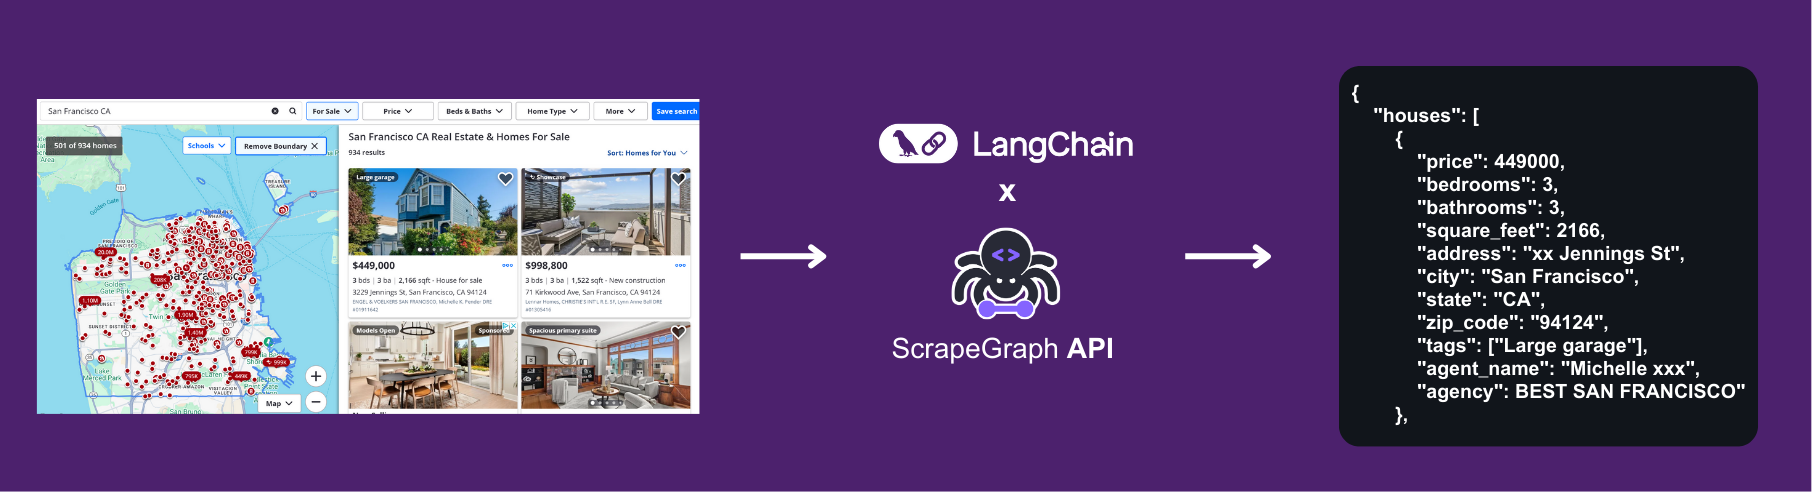

### 🔧 Install `dependencies`

In [1]:
%%capture
!pip install scrapegraph-py

### 🔑 Import `ScrapeGraph` API key

You can find the Scrapegraph API key [here](https://dashboard.scrapegraphai.com/)

In [2]:
import getpass
import os

if not os.environ.get("SGAI_API_KEY"):
    os.environ["SGAI_API_KEY"] = getpass.getpass("Scrapegraph API key:\n")

Scrapegraph API key:
··········


### 📝 Defining an `Output Schema` for Webpage Content Extraction


If you already know what you want to extract from a webpage, you can **define an output schema** using **Pydantic**. This schema acts as a "blueprint" that tells the AI how to structure the response.

<details>
  <summary>Pydantic Schema Quick Guide</summary>

Types of Schemas  

1. Simple Schema  
Use this when you want to extract straightforward information, such as a single piece of content.  

```python
from pydantic import BaseModel, Field

# Simple schema for a single webpage
class PageInfoSchema(BaseModel):
    title: str = Field(description="The title of the webpage")
    description: str = Field(description="The description of the webpage")

# Example Output JSON after AI extraction
{
    "title": "ScrapeGraphAI: The Best Content Extraction Tool",
    "description": "ScrapeGraphAI provides powerful tools for structured content extraction from websites."
}
```

2. Complex Schema (Nested)  
If you need to extract structured information with multiple related items (like a list of repositories), you can **nest schemas**.

```python
from pydantic import BaseModel, Field
from typing import List

# Define a schema for a single repository
class RepositorySchema(BaseModel):
    name: str = Field(description="Name of the repository (e.g., 'owner/repo')")
    description: str = Field(description="Description of the repository")
    stars: int = Field(description="Star count of the repository")
    forks: int = Field(description="Fork count of the repository")
    today_stars: int = Field(description="Stars gained today")
    language: str = Field(description="Programming language used")

# Define a schema for a list of repositories
class ListRepositoriesSchema(BaseModel):
    repositories: List[RepositorySchema] = Field(description="List of GitHub trending repositories")

# Example Output JSON after AI extraction
{
    "repositories": [
        {
            "name": "google-gemini/cookbook",
            "description": "Examples and guides for using the Gemini API",
            "stars": 8036,
            "forks": 1001,
            "today_stars": 649,
            "language": "Jupyter Notebook"
        },
        {
            "name": "TEN-framework/TEN-Agent",
            "description": "TEN Agent is a conversational AI powered by TEN, integrating Gemini 2.0 Multimodal Live API, OpenAI Realtime API, RTC, and more.",
            "stars": 3224,
            "forks": 311,
            "today_stars": 361,
            "language": "Python"
        }
    ]
}
```

Key Takeaways  
- **Simple Schema**: Perfect for small, straightforward extractions.  
- **Complex Schema**: Use nesting to extract lists or structured data, like "a list of repositories."  

Both approaches give the AI a clear structure to follow, ensuring that the extracted content matches exactly what you need.
</details>


In [3]:
from pydantic import BaseModel, Field
from typing import List, Optional

# Schema for a single house listing
class HouseSchema(BaseModel):
    price: int = Field(description="Price of the house in USD")
    bedrooms: int = Field(description="Number of bedrooms")
    bathrooms: int = Field(description="Number of bathrooms")
    square_feet: int = Field(description="Total square footage of the house")
    address: str = Field(description="Address of the house")
    city: str = Field(description="City where the house is located")
    state: str = Field(description="State where the house is located")
    zip_code: str = Field(description="ZIP code of the house location")
    tags: List[str] = Field(description="Tags like 'New construction' or 'Large garage'")
    agent_name: str = Field(description="Name of the listing agent. If not present or not sure write NA.")
    agency: str = Field(description="Agency listing the house. If not present or not sure write NA.")

# Schema containing a list of house listings
class HouseListingsSchema(BaseModel):
    houses: List[HouseSchema] = Field(description="List of house listings on Homes or similar platforms")


### 🚀 Initialize `SGAI Client` and start extraction

Initialize the client for scraping (there's also an async version [here](https://github.com/ScrapeGraphAI/scrapegraph-sdk/blob/main/scrapegraph-py/examples/async_smartscraper_example.py))

In [4]:
from scrapegraph_py import Client
import os

# Initialize the client with explicit API key
sgai_client = Client(api_key=os.environ.get("SGAI_API_KEY"), timeout=240)

Here we use `Smartscraper` service to extract structured data using AI from a webpage.


> If you already have an HTML file, you can upload it and use `Localscraper` instead.





In [5]:
# Request for Trending Repositories
repo_response = sgai_client.smartscraper(
    website_url="https://www.homes.com/real-estate-agents/tabi-deas/sxbn515/",
    user_prompt="Extract info about the houses visible on the page",
    output_schema=HouseListingsSchema,
)

Print the response

In [6]:
import json

# Print the response
request_id = repo_response['request_id']
result = repo_response['result']

print(f"Request ID: {request_id}")
print(json.dumps(result, indent=2))

Request ID: ec63e71f-f983-4e16-afaf-63bacaf5ce1f
{
  "houses": [
    {
      "price": 699900,
      "bedrooms": 2,
      "bathrooms": 2,
      "square_feet": 1750,
      "address": "459 Haven Point Dr",
      "city": "Treasure Island",
      "state": "FL",
      "zip_code": "33706",
      "tags": [],
      "agent_name": "Tabi Deas",
      "agency": "FUTURE HOME REALTY INC"
    },
    {
      "price": 329900,
      "bedrooms": 2,
      "bathrooms": 1,
      "square_feet": 925,
      "address": "11460 Park Blvd",
      "city": "Seminole",
      "state": "FL",
      "zip_code": "33772",
      "tags": [
        "Waterfront",
        "Coastal Mediterranean",
        "Open Concept"
      ],
      "agent_name": "Tabi Deas",
      "agency": "FUTURE HOME REALTY INC"
    },
    {
      "price": 349900,
      "bedrooms": 3,
      "bathrooms": 2,
      "square_feet": 1270,
      "address": "500 45th St S",
      "city": "Saint Petersburg",
      "state": "FL",
      "zip_code": "33711",
      "tag

### 💾 Save the output to a `CSV` file

Let's create a pandas dataframe and show the table with the extracted content

In [7]:
import pandas as pd

# Convert dictionary to DataFrame
df = pd.DataFrame(result["houses"])
df

,price,bedrooms,bathrooms,square_feet,address,city,state,zip_code,tags,agent_name,agency
0,699900,2,2,1750,459 Haven Point Dr,Treasure Island,FL,33706,[],Tabi Deas,FUTURE HOME REALTY INC
1,329900,2,1,925,11460 Park Blvd,Seminole,FL,33772,"[Waterfront, Coastal Mediterranean, Open Concept]",Tabi Deas,FUTURE HOME REALTY INC
2,349900,3,2,1270,500 45th St S,Saint Petersburg,FL,33711,"[Corner Lot, Alley Access, Key West-style Bung...",Tabi Deas,FUTURE HOME REALTY INC


Save it to CSV

In [8]:
# Save the DataFrame to a CSV file
csv_file = "houses_forsale.csv"
df.to_csv(csv_file, index=False)
print(f"Data saved to {csv_file}")

Data saved to houses_forsale.csv


## 🔗 Resources


<p align="left">
  <img src="https://raw.githubusercontent.com/VinciGit00/Scrapegraph-ai/main/docs/assets/api-banner.png"
       alt="ScrapeGraph API Banner" width="600">
</p>


- 🚀 **Get your API Key:** [ScrapeGraphAI Dashboard](https://dashboard.scrapegraphai.com)  
- 🐙 **GitHub:** [ScrapeGraphAI GitHub](https://github.com/scrapegraphai)  
- 💼 **LinkedIn:** [ScrapeGraphAI LinkedIn](https://www.linkedin.com/company/scrapegraphai/)  
- 🐦 **Twitter:** [ScrapeGraphAI Twitter](https://twitter.com/scrapegraphai)  
- 💬 **Discord:** [Join our Discord Community](https://discord.gg/uJN7TYcpNa)  

Made with ❤️ by the [ScrapeGraphAI](https://scrapegraphai.com) Team  
